In [72]:
import pandas as pd
from pathlib import Path
import seaborn as sns
from backend.src.backend.constants import DATA_PATH

In [56]:
ROOT = Path ("/Users/lillmossi/Documents/Github/fullstack_azure_python/backend/data/lunar.csv")

df = pd.read_csv(DATA_PATH, na_values=["-"])

df.head()

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Quincena Solar Eclipse,Gamma,Penumbral Magnitude,Umbral Magnitude,Latitude,Longitude,Penumbral Eclipse Duration (m),Partial Eclipse Duration (m),Total Eclipse Duration (m)
0,1,-1999 June 26,14:13:28,46437,-49456,17,N,t-,-1.0981,0.8791,-0.1922,24S,22W,268.8,NaN,NaN
1,2,-1999 November 21,20:23:49,46427,-49451,-16,N,-a,-1.1155,0.8143,-0.1921,15N,98W,233.4,NaN,NaN
2,3,-1998 May 17,05:47:36,46416,-49445,-11,P,-t,0.8988,1.2105,0.2069,13S,89E,281.7,102.7,NaN
3,4,-1998 November 11,05:15:58,46404,-49439,-6,P,-a,-0.4644,2.0382,0.9740,12N,113E,343.4,200.8,NaN
4,5,-1997 May 6,18:57:01,46392,-49433,-1,T+,pp,0.1003,2.6513,1.6963,11S,92W,322.8,213.5,98.2


In [57]:
df.isna().sum().sort_values(ascending=False)


Total Eclipse Duration (m)        8585
Partial Eclipse Duration (m)      4378
Catalog Number                       0
Calendar Date                        0
Lunation Number                      0
Saros Number                         0
Eclipse Time                         0
Delta T (s)                          0
Quincena Solar Eclipse               0
Eclipse Type                         0
Gamma                                0
Penumbral Magnitude                  0
Latitude                             0
Umbral Magnitude                     0
Penumbral Eclipse Duration (m)       0
Longitude                            0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df["Eclipse Type"].value_counts(dropna=False)

Eclipse Type
P     4207
N     4020
T     1405
T+    1042
T-    1032
Nx     141
Ne     115
Nb     102
Name: count, dtype: int64

In [60]:
df.describe()

,Catalog Number,Delta T (s),Lunation Number,Saros Number,Gamma,Penumbral Magnitude,Umbral Magnitude,Penumbral Eclipse Duration (m),Partial Eclipse Duration (m),Total Eclipse Duration (m)
count,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,7686.000000,3479.000000
mean,6032.500000,12116.476044,-18531.392822,80.505056,0.002490,1.418656,0.400175,269.971941,174.768085,80.824289
std,3482.721158,13584.785584,17887.218741,48.416007,0.910505,0.832263,0.832954,79.945444,49.842709,22.612341
min,1.000000,-6.000000,-49456.000000,-20.000000,-1.582700,0.000400,-1.095800,5.200000,2.500000,1.700000
25%,3016.750000,962.000000,-33923.250000,40.000000,-0.788825,0.684425,-0.334000,223.100000,146.300000,68.100000
50%,6032.500000,5597.000000,-18445.500000,80.000000,0.001750,1.417450,0.400450,295.000000,191.200000,89.200000
75%,9048.250000,20901.500000,-3067.750000,121.000000,0.791725,2.136900,1.117925,327.800000,212.300000,98.400000
max,12064.000000,46437.000000,12378.000000,183.000000,1.579100,2.908900,1.882100,379.500000,236.000000,106.600000


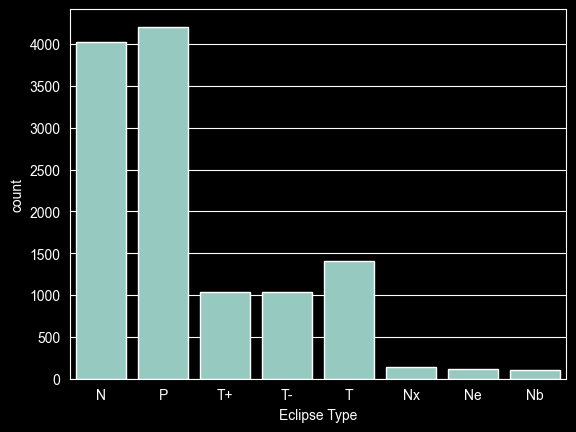

In [61]:
sns.countplot(data=df, x="Eclipse Type")

numeric_cols = [
    "Delta T (S)",
    "Gamma",
    "Penumbral Magnitude",
    "Penumbral Eclipse Duration (m)",
    "Partial Eclipse Duration (m)",
    "Total Eclipse Duration (m)",
]


<Axes: xlabel='Eclipse Type', ylabel='Total Eclipse Duration (m)'>

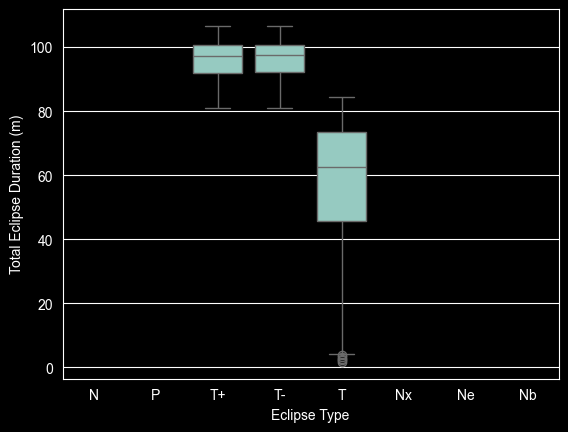

In [62]:
sns.boxplot(data=df, x ="Eclipse Type", y="Total Eclipse Duration (m)")


<Axes: >

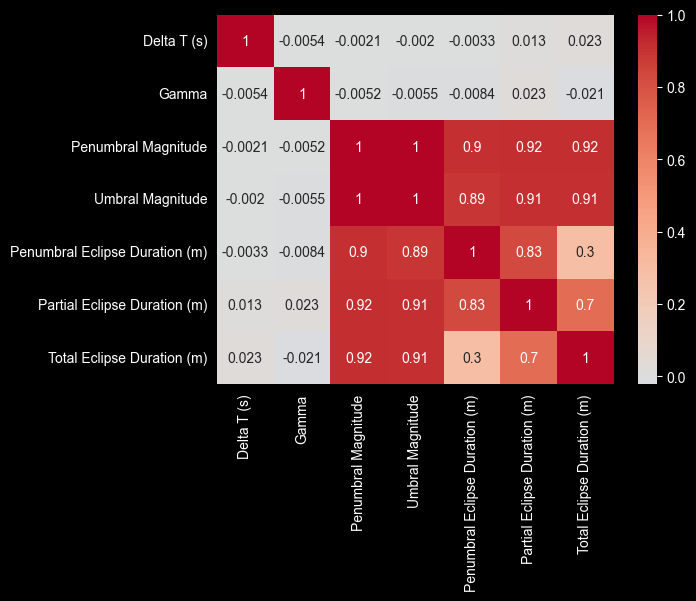

In [63]:
numeric_cols = [
    "Delta T (s)",
    "Gamma",
    "Penumbral Magnitude",
    "Umbral Magnitude",
    "Penumbral Eclipse Duration (m)",
    "Partial Eclipse Duration (m)",
    "Total Eclipse Duration (m)",
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

In [64]:
duration_cols = [
    "Penumbral Eclipse Duration (m)",
    "Partial Eclipse Duration (m)",
    "Total Eclipse Duration (m)",
]

duration_summary = (
    df.groupby("Eclipse Type")[duration_cols].agg(["count", "mean", "median"]).round(2)
)

duration_summary

Penumbral Eclipse Duration (m)                  \
                                      count    mean  median   
Eclipse Type                                                  
N                                      4020  186.22  194.70   
Nb                                      102   53.54   54.70   
Ne                                      115   56.47   57.30   
Nx                                      141  282.80  285.60   
P                                      4207  302.67  301.80   
T                                      1405  334.19  331.80   
T+                                     1042  343.85  340.55   
T-                                     1032  344.33  343.30   

             Partial Eclipse Duration (m)                  \
                                    count    mean  median   
Eclipse Type                                                
N                                       0     NaN     NaN   
Nb                                      0     NaN     NaN   
Ne                                      0     NaN     NaN   
Nx                                      0     NaN     NaN   
P                                    4207  141.84  151.80   
T                                    1405  206.45  205.40   
T+                                   1042  219.97  219.25   
T-                                   1032  220.21  220.20   

             Total Eclipse Duration (m)                
                                  count   mean median  
Eclipse Type                                           
N                                     0    NaN    NaN  
Nb                                    0    NaN    NaN  
Ne                                    0    NaN    NaN  
Nx                                    0    NaN    NaN  
P                                     0    NaN    NaN  
T                                  1405  58.24  62.50  
T+                                 1042  96.07  97.10  
T-                                 1032  96.17  97.55

<Axes: title={'center': 'Number of Eclipses by 100-Year Period'}, xlabel='Period'>

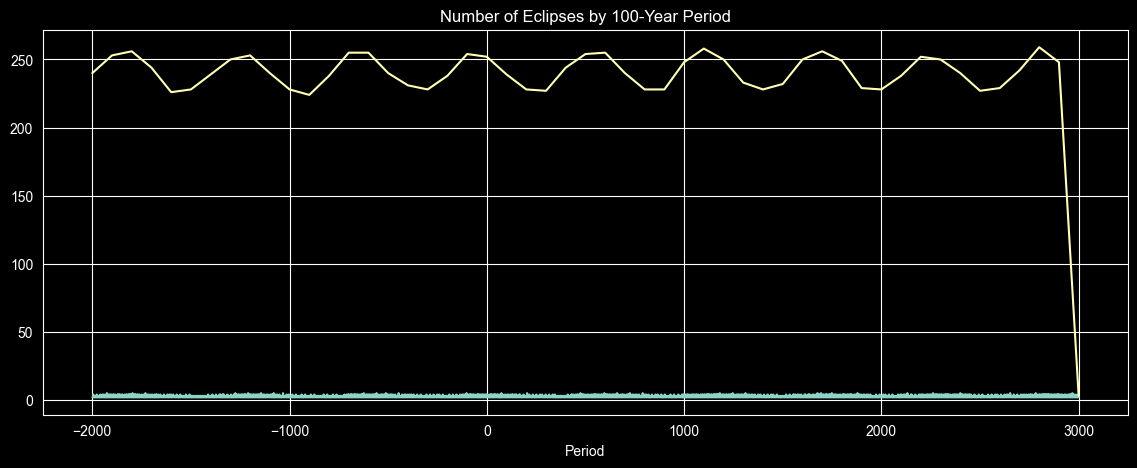

In [71]:
df["Year"] = df["Calendar Date"].str.extract(r"^(-?\d+)").astype(int)

yearly_counts = df.groupby("Year").size()

yearly_counts.plot(figsize=(14, 5), title="Number of Eclipse by Year")

df["Period"] = (df["Year"] // 100) * 100

df.groupby("Period").size().plot(
    figsize=(14, 5),
    title="Number of Eclipses by 100-Year Period"
)